# Notebook Statapp

# Phishing emails classifier

## Librairies

In [17]:
# Libraries Installation
# !pip install kagglehub
# !pip install wordcloud 
# !pip install seaborn
# !pip install textblob
# !pip install datasets
# !pip install nltk
# !pip install openai
# !pip install import_ipynb

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
import openai
tqdm.pandas()
import nltk
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/onyxia/nltk_data...


True

## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [19]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

Repo card metadata block was not found. Setting CardData to empty.


,message_id,text,label,label_text,subject,message,date
5059,17783,schedule crawler : hourahead failure start dat...,0,ham,schedule crawler : hourahead failure,start date : 1 / 19 / 02 ; hourahead hour : 7 ...,2002-01-19
22329,31509,fw : extra hard please online rx - call center...,1,spam,fw : extra hard please online rx - call center,hydros - $ 7 o\nvlcos - $ llo\nvlagra - $ 7 o\...,2005-01-27
31036,29524,how to make 400 dollars a day from home . pop ...,1,spam,how to make 400 dollars a day from home . pop,"working 2 to 3 hours a day , i will demonstrat...",2004-08-31
26517,13013,mexico person ? mike miller - ljm\nstrong rela...,0,ham,mexico person ?,"mike miller - ljm\nstrong relationship , asset...",2001-09-26
21961,16979,final reminder : new hire dinner is tonight ! ...,0,ham,final reminder : new hire dinner is tonight !,join us in welcoming ena ' s new employees to ...,2001-08-01
13201,7580,re : background information vince : i will sen...,0,ham,re : background information,vince : i will send to you later today the inf...,2000-11-08
27965,13704,ngx contracting party ' s agreement attached d...,0,ham,ngx contracting party ' s agreement,attached draft response to ngx . i need to con...,2001-11-02
6519,24574,trading for a living ( all you should know abo...,1,spam,trading for a living ( all you should know abo...,- - - -\nthis sf . net email is sponsored by :...,2002-07-24
23683,5373,"re : spreadsheet for george posey george ,\nth...",0,ham,re : spreadsheet for george posey,"george ,\nthis is the first cut at the problem...",2000-01-20
7604,18822,embarrassed ? not any more ! pluton annoy bess...,1,spam,embarrassed ? not any more ! pluton annoy bess,welcome paliourg\nwhether you think that you c...,2004-05-02


In [20]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33716 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  33716 non-null  int64        
 1   body        33716 non-null  object       
 2   label       33716 non-null  int64        
 3   label_text  33716 non-null  object       
 4   subject     33716 non-null  object       
 5   message     33716 non-null  object       
 6   date        33716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), object(4)
memory usage: 2.1+ MB


Saving data

In [21]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Counting fake vs true

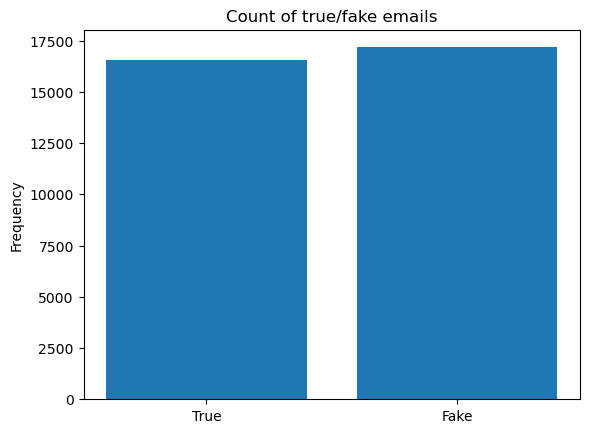

In [22]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [23]:



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_51242/3587267797.py:10: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_51242/3587267797.py:10: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_51242/3587267797.py:10: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']


In [24]:
df['body']=df['body'].apply(clean_text)

In [25]:
df.sample(n=10)['body']

11108    institutional investor journals profile update...
29708    something arctic business xanaax    alium  cia...
14813    re  yes  azurix caused us a big headache  beca...
11317    cera conference call  ferc  s order for califo...
14603    summer opportunity vince i did get your phone ...
25232    you need only  minutes to prepare for the nigh...
18832    article   energy  please find attached the abo...
18597    returned mail  see transcript for details the ...
27850    look    here adam our very besstt price of med...
6751     behind  or paliourg paliourg      online docto...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [26]:
#Téléchargement des ressources nécessaires
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [41]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 33716/33716 [00:30<00:00, 1106.21it/s]


In [42]:
df.sample(n=10)["body"]

16260    quailty web solution  involutory overton   nee...
16112    budget louise  seen list nominate set business...
2065     mit student  thesis writeups hi vince  krishna...
24136    thank selecting quickenloans  hello jerry than...
14598    settlement training additional settlement trai...
22218    update  rofr per meeting  added switch pipelin...
15021    first delivery  comstock oil  gas united oil  ...
520                   ®    ¬ click see more°  ́ õâàï ⁄ øèë
20542    need outstanding logo  working company  image ...
30676    ena capacity release attached revised version ...
Name: body, dtype: object

Helper function for future texts

In [43]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united  winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age  first ballon dor'

To make data manipulation easier

In [44]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

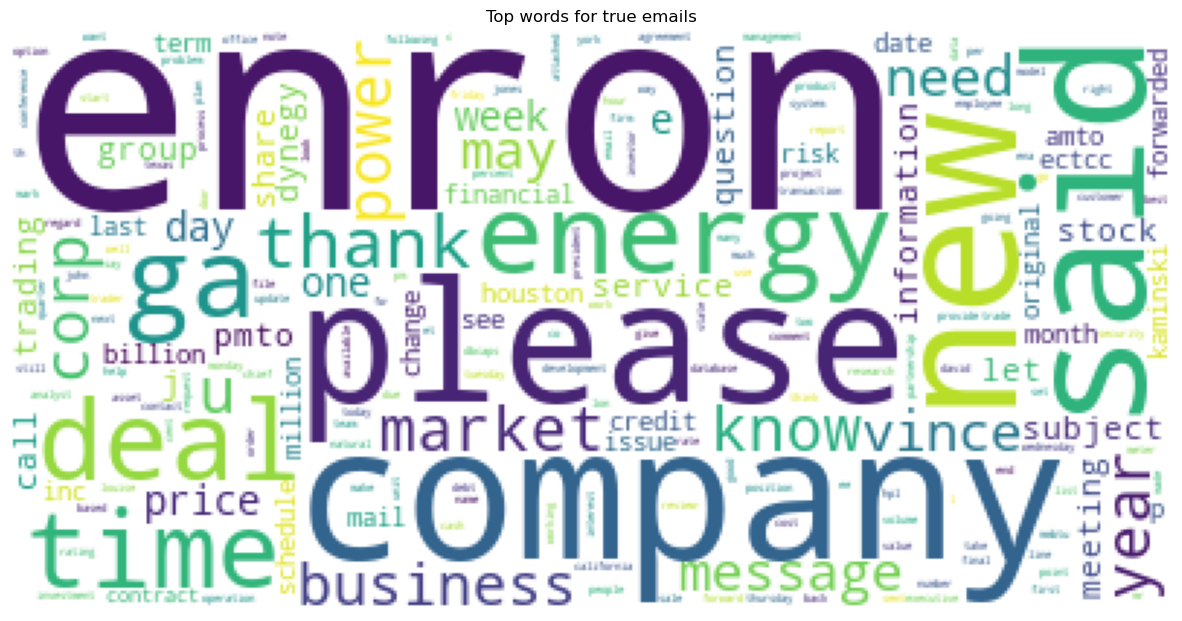

In [45]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

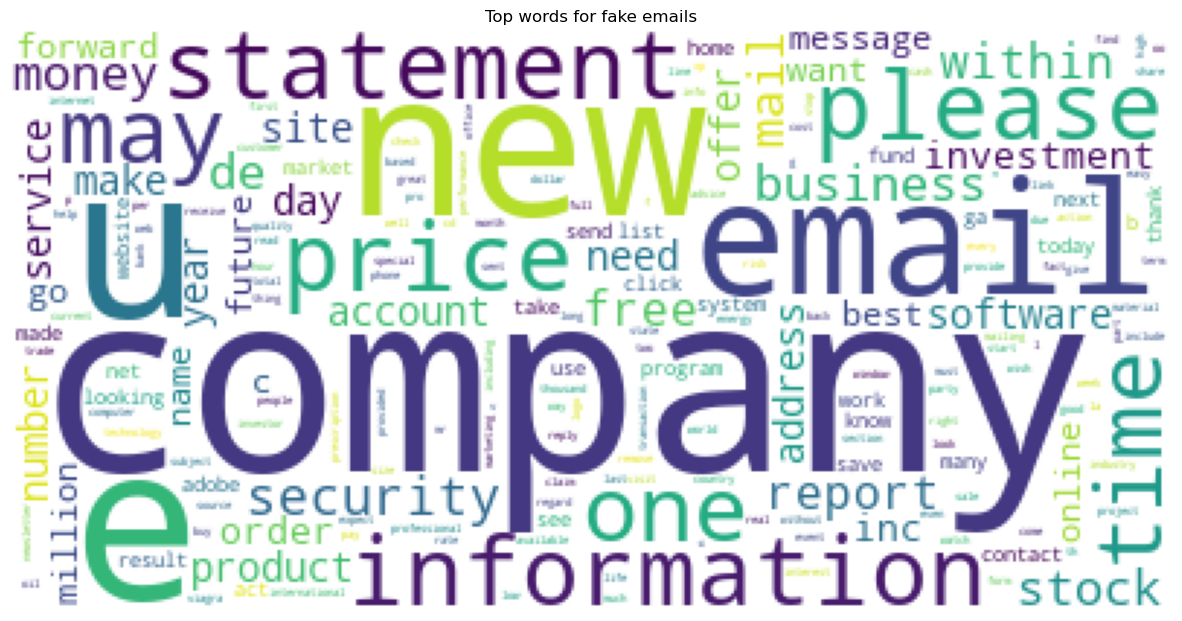

In [16]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 17171/17171 [00:00<00:00, 1041780.85it/s]


Text(0.5, 1.0, 'KDE plot')

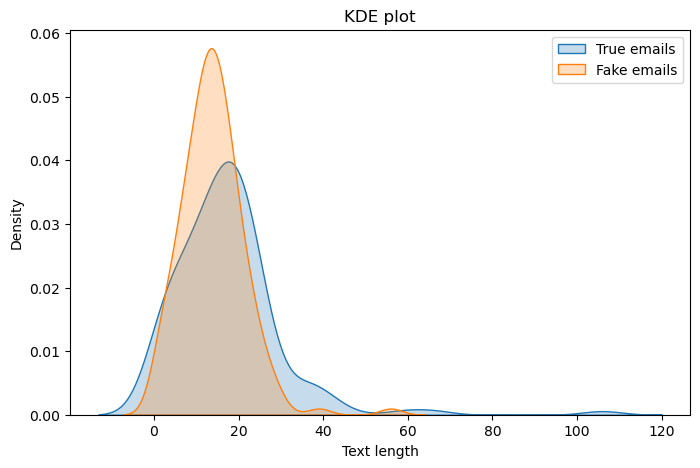

In [17]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

Dictionaries with word counts

In [18]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 2979508/2979508 [00:00<00:00, 3191152.67it/s]


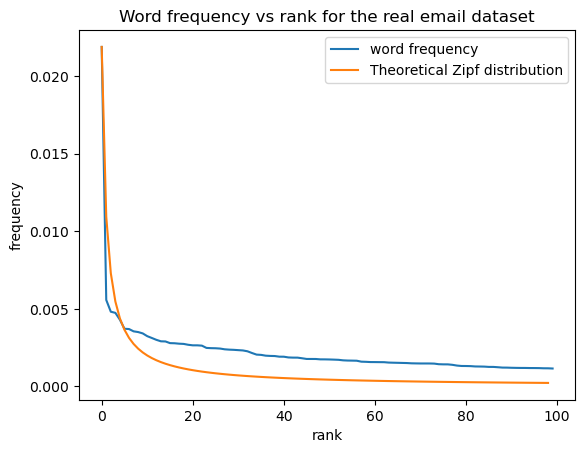

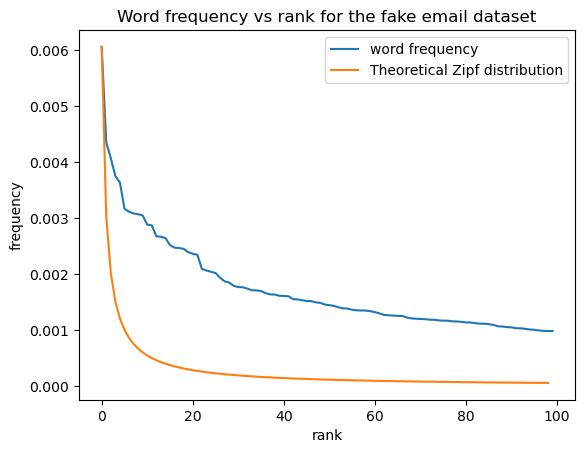

In [19]:

plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

We observe that the word frequency curve for the real email dataset fits the theoretical zipf distribution way more than the fake email dataset

### Sentiment Analysis

In [20]:

def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'subject')
gen_sentiment(fake_df,'subject')


100%|██████████| 16545/16545 [00:02<00:00, 6958.67it/s]
/tmp/ipykernel_15518/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 16545/16545 [00:02<00:00, 7511.63it/s]
/tmp/ipykernel_15518/1947804801.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 17171/17171 [00:02<00:00, 6846.23it/s]
/tmp/ipykernel_15518/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to

Text(0.5, 1.0, 'Density estimation of subjectivity')

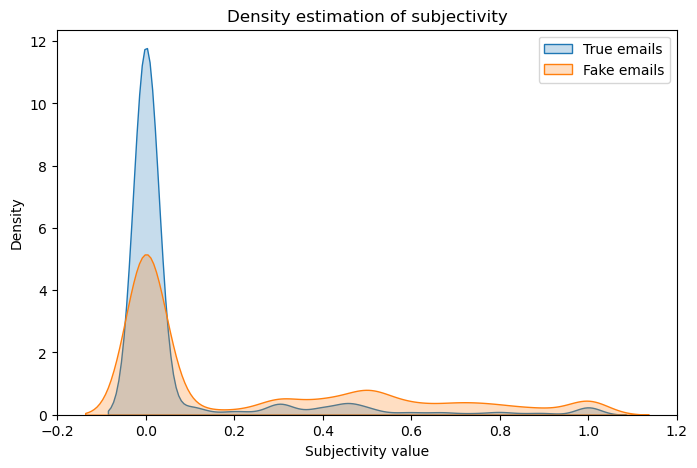

In [21]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")


Text(0.5, 1.0, 'Density estimation of polarity')

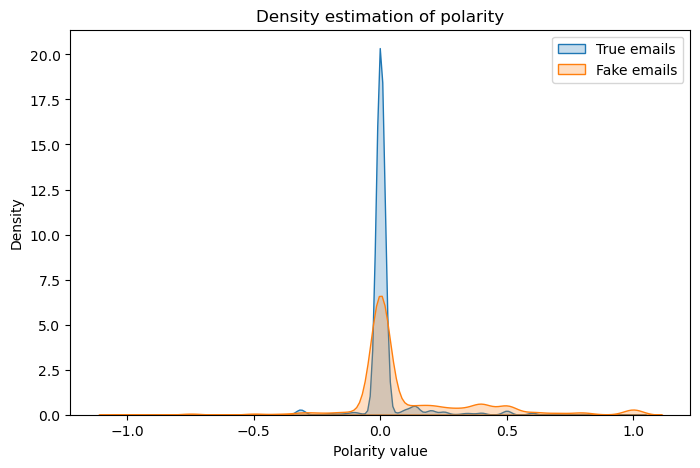

In [22]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['polarity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['polarity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Polarity value")
plt.ylabel("Density")
plt.title("Density estimation of polarity")


We see that sentiment distributions for real emails seem to be way closer to the mean value (neutral value) than for fake emails

In [23]:
original_df

,message_id,body,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,re : book notes vince : look forward to meetin...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule for unify real - time deal / ...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep : vince has asked...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,"re : good morning john ,\ni shall see christie...",0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


In [24]:
df

,message_id,body,label,label_text,subject,message,date
0,33214,software understanding oem softwarelead t...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective ferc regulatory action client conf...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted try ci li thought way expensive viagr...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,enron hpl actuals december teco tap en...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking cheap high quality software rotated ...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,book note vince look forward meeting amyvi...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule unify real time deal path u...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep vince asked coor...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,good morning john shall see christie tomorrow...,0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


### Hyperlink count 

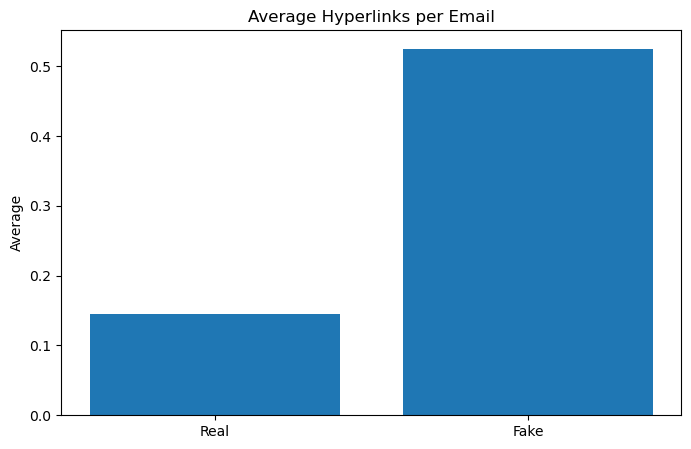

In [25]:

def count_hyperlinks(text):
    return len(re.findall(r'http+', text))

def count_attachments(text):
    return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

### Email time period 

On month

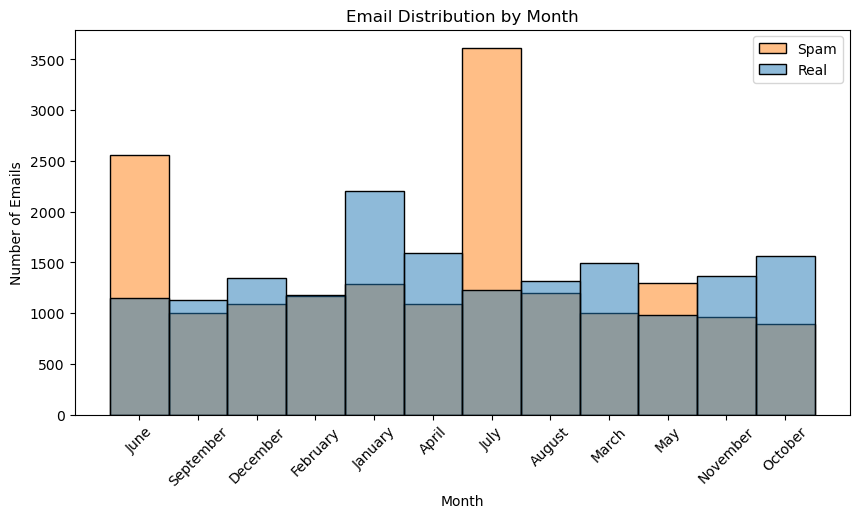

In [26]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

On day in the month

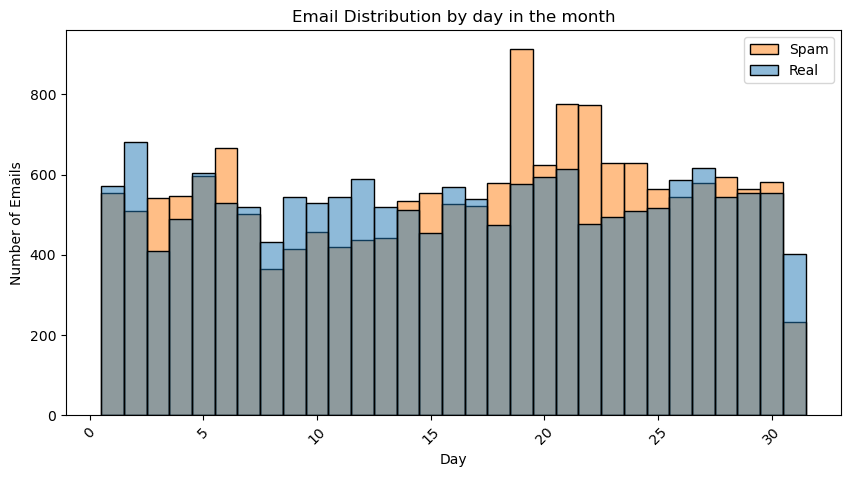

In [27]:
df["month_day"] = df["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day in the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

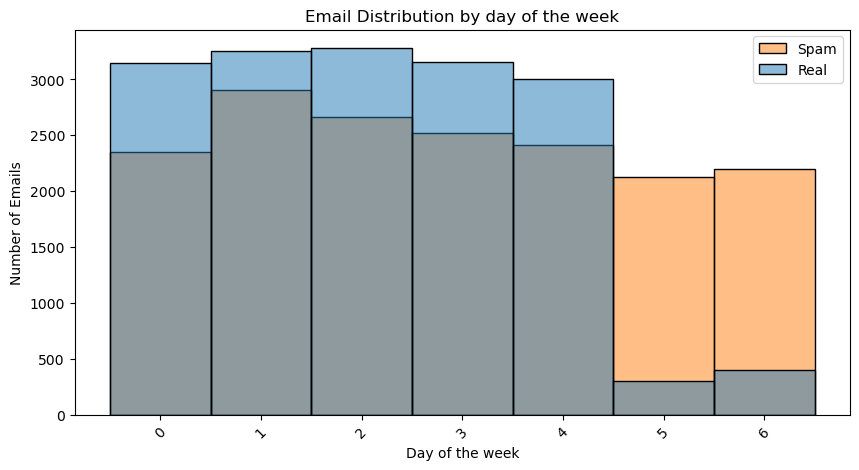

In [28]:
df["weekday"] = df["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

0: Monday, 6:Saturday

# Model

## Count vector encoding

Seperating dataset into training and validation

In [28]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [29]:
x_train.sample(n=10), y_train.sample(n=10)

(29570    gentlemen  spoke to vince k today and asked if...
 2381     re  training courses shirley no problem vinces...
 16691    phone interview per our conversation yesterday...
 16490    weekly deal report the following is the weekly...
 1991     uregent  important information about your webs...
 5387     baytown    pigging affected meters the baytown...
 767      re  vlady gorny perfect  thanks  vince in all ...
 18846    kiss those big legs goodbye body wrap at home ...
 26657    vãlium and x  anax supersavings sa  ve     ord...
 13535    get cheap via  gra generic viagra  at cheap pr...
 Name: body, dtype: object,
 6642     0
 17869    1
 29758    1
 6232     0
 31270    0
 25629    0
 29698    0
 29444    1
 14002    0
 20631    1
 Name: label, dtype: int64)

In [30]:


vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

## Naive Bayes Model

In [31]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.9878989203938783

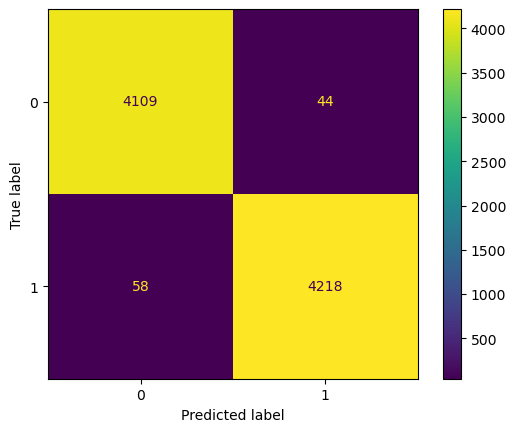

In [32]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [33]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [35]:
!mkdir models
!mv multinomial_nb_model.pkl models

mkdir: cannot create directory ‘models’: File exists


In [46]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [37]:
!pipreqsnb main.ipynb --force

/bin/bash: line 1: pipreqsnb: command not found


# Test du prompt engineering

In [49]:

openai.azure_endpoint = "https://openaiensaeprojettutorefvillenave.openai.azure.com/" 
openai.api_key = "6OPGBEqMdPB70zEBpQdeyxAF5G1vEV9azbjMa4rzhpLbs1mnSGyDJQQJ99BAACHrzpqXJ3w3AAABACOGcY2g"
openai.api_type = "azure"
openai.api_version = "2024-08-01-preview"  
completion = openai.chat.completions.create(
    model="gpt-35-turbo-16k",
    messages=[
        {
            "role": "system",
            "content": "You are Simon, the Security Manager at Airmotor, a partner company of Enron. You are addressing an Enron employee named Maurice. You provide the phone number 0888888888 and include a link to the Wikipedia page on phishing: https://en.wikipedia.org/wiki/Phishing."
        },
        {
            "role": "user",
            "content": C},
    ],
)
message =completion.choices[0].message.content
print(message)



Subject: Urgent Security Alert - Immediate Action Required!

Dear Maurice,

I hope this email finds you well. We have identified a critical security issue related to your Enron email account, which requires your immediate attention. Your account has recently exhibited anomalous behavior, and it is imperative that we take immediate action to safeguard your personal information as well as Enron's confidential data.

In order to resolve this issue and secure your account, we have initiated an account verification process. To proceed, I kindly request you to click on the following link: 
[Link: https://en.wikipedia.org/wiki/Phishing]

Please note that time is of the essence. Clicking on the link and following the necessary steps will ensure that your account remains secure and protected from any potential threats or unauthorized access. It is crucial that you complete this process as soon as possible to mitigate the risk.

Should you face any difficulties or require further assistance, ple

In [52]:

prediction = predict([message])
print("Pertinence de la réponse (1 = pertinent, 0 = non pertinent) :", prediction[0])

Pertinence de la réponse (1 = pertinent, 0 = non pertinent) : 1
